Today's topics:
* computing a quantity the file doesn't contain
* `np.linspace`
* `np.exp`
* dividing by zero

# Why is the mirror gold?

<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/b/b1/Gold-coated_Primary_Mirror_Segment_%284976532481%29.jpg/960px-Gold-coated_Primary_Mirror_Segment_%284976532481%29.jpg" alt="An engineer in a white cleanroom suit inspecting a row of six hexagonal telescope mirror segments, each with a bright gold reflective surface" width=520/>

Photo by NASA's James Webb Space Telescope, public domain,
[via Wikimedia Commons](https://commons.wikimedia.org/wiki/File:Gold-coated_Primary_Mirror_Segment_(4976532481).jpg).

Last time we said gold makes a good infrared mirror because its $k$ is large.

We never put a number on it.

The file we have holds $n$ and $k$, and neither of those is a reflectance. Today
we compute one.

*What fraction of the light does each of our four materials send back?*

In [1]:
#@title Find the data file and split it by material (click ▶ to run) { display-mode: "form" }
import os

import pandas as pd

_file = 'optical_constants.csv'
_github = f'https://raw.githubusercontent.com/wfreinhart/matse219/main/datasets/{_file}'
_local = next(
    (p for p in (f'datasets/{_file}', f'../datasets/{_file}', f'../../datasets/{_file}',
                 f'../../../datasets/{_file}')
     if os.path.exists(p)),
    None,
)
source = _local if _local else _github

try:
    _table = pd.read_csv(source)
except Exception as e:
    raise RuntimeError(
        f"Could not load '{_file}'. If you are in Colab, check your internet "
        f"connection and that the file exists at {_github}"
    ) from e

# Picking out one material's rows is boolean indexing, which is L11. Everything
# else in today's lecture happens in the open.
materials = {
    name: _table[_table['material'] == name].sort_values('wavelength_um').reset_index(drop=True)
    for name in ('silicon', 'BK7', 'fused_silica', 'gold')
}

print(f'Ready. Four materials split out of {_file}:')
for _name, _frame in materials.items():
    print(f'  {_name:14s} {len(_frame):2d} wavelengths')

Ready. Four materials split out of optical_constants.csv:
  silicon        11 wavelengths
  BK7            13 wavelengths
  fused_silica   10 wavelengths
  gold           13 wavelengths


The same four materials and the same dictionary as last time.

In [2]:
si = materials['silicon']
au = materials['gold']
bk7 = materials['BK7']
silica = materials['fused_silica']

display(au.head())

,material,wavelength_um,n,k
0,gold,0.1879,1.28,1.188
1,gold,0.2033,1.33,1.277
2,gold,0.2214,1.30,1.427
3,gold,0.2426,1.32,1.577
4,gold,0.2689,1.38,1.803


# Reflectance from two columns

At normal incidence the fraction reflected is

$$R = \frac{(n-1)^2 + k^2}{(n+1)^2 + k^2}$$

Both columns appear in it, so this is the first time we use two of them in one
expression.

In [3]:
n = au['n']
k = au['k']

R_gold = ((n - 1)**2 + k**2) / ((n + 1)**2 + k**2)

print(R_gold)

0     0.225386
1     0.246419
2     0.290231
3     0.329041
4     0.380833
5     0.386111
6     0.386595
7     0.406732
8     0.401478
9     0.882363
10    0.974463
11    0.979520
12    0.980989
dtype: float64


Every operation ran once per wavelength, the way elementwise arithmetic always has.

What came back is a new column, the same length as the two we started with. It's the
first column in this course we made rather than read.

# All four materials

Let's do the same arithmetic for the other three and put them on one figure.

In [4]:
R_silicon = ((si['n'] - 1)**2 + si['k']**2) / ((si['n'] + 1)**2 + si['k']**2)
R_bk7 = ((bk7['n'] - 1)**2 + bk7['k']**2) / ((bk7['n'] + 1)**2 + bk7['k']**2)
R_silica = ((silica['n'] - 1)**2 + silica['k']**2) / ((silica['n'] + 1)**2 + silica['k']**2)

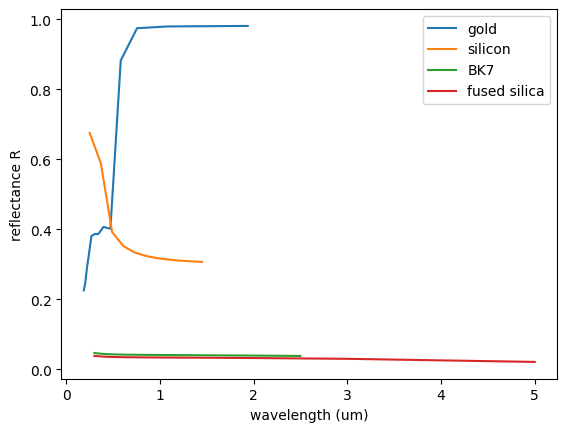

In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
ax.plot(au['wavelength_um'], R_gold, label='gold')
ax.plot(si['wavelength_um'], R_silicon, label='silicon')
ax.plot(bk7['wavelength_um'], R_bk7, label='BK7')
ax.plot(silica['wavelength_um'], R_silica, label='fused silica')
ax.set_xlabel('wavelength (um)')
ax.set_ylabel('reflectance R')
ax.legend()

There's the answer to the question we opened with.

Gold starts near a quarter in the ultraviolet and climbs to 98% in the infrared!

The two glasses sit near 4% across the whole range, which is why you can see
through a window and still catch your reflection in it at night.

Silicon is in between and falling.

> Note: the four lines stop at different places because each material was measured
> over its own range of wavelengths.

### [Check your understanding]

1. Compute silicon's reflectance at the shortest wavelength in its table and print it.
2. Make a `fig, ax` and plot gold's reflectance against its wavelengths.
3. Label both axes.
4. Add silicon to the same figure with a `label=`, and draw the legend.

# How far the light gets

Reflectance says what comes back. It doesn't say what happens to the rest.

Light that enters a material fades as it goes, and the depth at which it has faded
to about a third is

$$d = \frac{\lambda}{4 \pi k}$$

Last time we put that number in a table and asked you to take it on trust. Now we
can compute it.

In [6]:
import numpy as np

depth_gold = au['wavelength_um'] / (4 * np.pi * au['k'])
depth_silicon = si['wavelength_um'] / (4 * np.pi * si['k'])

print(depth_gold)

0     0.012586
1     0.012669
2     0.012346
3     0.012242
4     0.011868
5     0.012676
6     0.014567
7     0.016201
8     0.020288
9     0.016180
10    0.013245
11    0.012109
12    0.011186
dtype: float64


Red light gets about 16 nanometers into gold. The table last time said 13, and it
was reading a slightly different wavelength off the same curve.

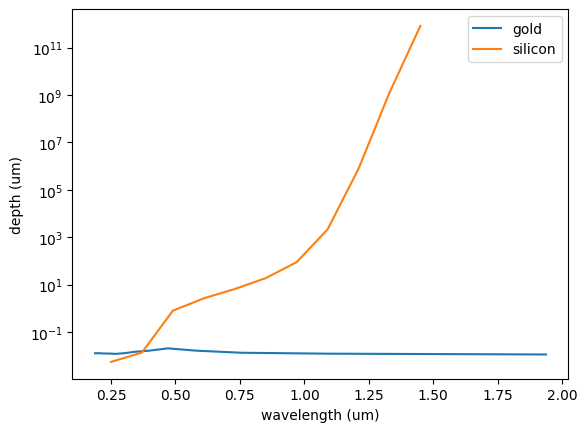

In [7]:
fig, ax = plt.subplots()
ax.plot(au['wavelength_um'], depth_gold, label='gold')
ax.plot(si['wavelength_um'], depth_silicon, label='silicon')
ax.set_xlabel('wavelength (um)')
ax.set_ylabel('depth (um)')
ax.set_yscale('log')
ax.legend()

Gold is a flat line near a hundredth of a micrometer.

Silicon climbs through fourteen powers of ten.

A log axis is the only way both fit on one figure, which is the same argument we
made about $k$ itself.

# When k is exactly zero

Fused silica hasn't appeared on either of the last two figures. Let's see what
happens when we ask for its depth.

In [8]:
depth_silica = silica['wavelength_um'] / (4 * np.pi * silica['k'])

print(depth_silica.head())

0    inf
1    inf
2    inf
3    inf
4    inf
dtype: float64


`inf` is Python's infinity. It's what division returns when the bottom is zero
and the top is not.

Nothing went wrong. We asked how deep light gets into a material that this file
says absorbs none of it, and infinitely deep is the correct answer to that question.

> Note: a column of exact zeros is usually a gap in the measurement rather than a
> perfect material. Real fused silica does absorb past about 4 um, and this file
> doesn't record it.

# How thick can the detector be?

A silicon detector has to be thick enough to absorb the light it's meant to
register.

The fraction still travelling after a thickness $t$ is

$$T = e^{-4 \pi k t / \lambda}$$

We have $k$ and $\lambda$.

We don't have a thickness, because a thickness isn't a measurement. It's something
we choose.

In [9]:
thickness_um = np.linspace(0, 20, 100)

print(thickness_um[:5])
print(len(thickness_um))

[0.         0.2020202  0.4040404  0.60606061 0.80808081]
100


`np.linspace` takes a start, a stop and a count. It returns that many evenly spaced
values, with both ends included.

Every x axis we've drawn so far came out of a file. This one we made.

Text(0, 0.5, 'fraction still travelling')

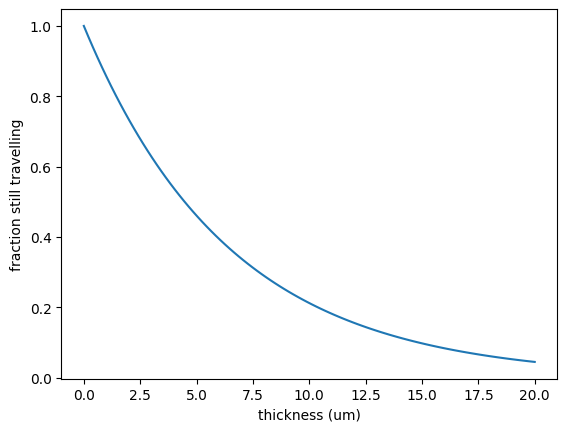

In [10]:
wavelength_um = 0.73
k_red = 0.009

T = np.exp(-4 * np.pi * k_red * thickness_um / wavelength_um)

fig, ax = plt.subplots()
ax.plot(thickness_um, T)
ax.set_xlabel('thickness (um)')
ax.set_ylabel('fraction still travelling')

`np.exp` raises $e$ to each value it's given, once per entry, like every other
NumPy function we've used.

The curve crosses a third at about six and a half micrometers, which is the number
last week's table gave for red light in silicon.

A detector thinner than that passes most of the light straight through and
registers little of it.

### [Check your understanding]

1. Make a thickness axis from 0 to 100 nanometers with `np.linspace`.
2. Compute the transmission through gold at red light, using $k = 4.5$.
3. Plot it with both axes labeled.
4. Read off roughly where the curve crosses a third.

# Summary

* Two columns can go into one expression, and the result is a new column.
* `np.linspace(start, stop, count)` makes values we choose rather than values we measured.
* `np.exp` raises $e$ to every entry.
* Dividing by zero gives `inf`, which is an answer and not an error.
* A log axis fits quantities that span many powers of ten.

## Further reading

* The data: [Polyanskiy, *Scientific Data* **11**, 94 (2024)](https://doi.org/10.1038/s41597-023-02898-2),
  the refractiveindex.info database, CC BY 4.0. Browse it at
  [refractiveindex.info](https://refractiveindex.info).
* [Fresnel equations](https://en.wikipedia.org/wiki/Fresnel_equations), where the
  reflectance formula comes from, and what it looks like at other angles.